# Instacart Market Basket Analysis

## Importing the required libraries

In [1]:
# Import the libraries you'll need for this analysis
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the datasets
# Note: These files use semicolon (;) as the separator instead of comma
orders         = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products       = pd.read_csv('/datasets/products.csv', sep=';')
departments    = pd.read_csv('/datasets/departments.csv', sep=';')
aisles         = pd.read_csv('/datasets/aisles.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

Data Analysis

In [ ]:
# displaying orders
orders

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478962,3210681,5617,5,1,14,7.0
478963,3270802,112087,2,3,13,6.0
478964,885349,82944,16,2,11,6.0
478965,216274,4391,3,3,8,8.0


In [ ]:
# displaying products
products

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


Initial data inspection was completed for all datasets to confirm column types, row counts, and general structure before cleaning.

In [ ]:
# Summary information for the orders dataset
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


The non-null counts reveal missing values in columns where the count is below the total number of rows (478,952 in orders).

In [ ]:
# Summary information for the order_products dataset
order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


The same `.info()` review was applied to the remaining datasets to identify missing values and confirm schema consistency.

## Find and Remove Missing Values

We noticed that some columns contain missing values.

### `products` Data Frame

We will begin by addressing the missing values in the `products` data frame.

In [7]:
# Display rows where the product_name column has missing values
print(products[products['product_name'].isna()])

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


It seems suspicious that all rows with missing `product_name` might be associated with `aisle_id` 100 and `department_id` 21. Let’s verify this by checking if any rows with missing `product_name` have an `aisle_id` different from 100 and 21. This will help us confirm if the issue is isolated to this aisle or spread across others.

In [8]:
# Combine conditions to check for missing product names in aisles other than 100
print(products[(products['product_name'].isna()) & ~(products['aisle_id'] == 100)])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [9]:
# Combine conditions to check for missing product names in aisles other than 21
print(products[(products['product_name'].isna()) & ~(products['department_id'] == 21)])
# aisles other than 21 seems to be a typo

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


To better understand the missing product_name values, let’s determine what department_id 21 and aisle_id 100 represent by referencing the departments and aisles tables.

In [10]:
# What is this aisle and department?
print(aisles.iloc[99])
print(departments.iloc[20])
# department 21 is 'missing', aisle 100 is also 'missing'

aisle_id        100
aisle       missing
Name: 99, dtype: object
department_id         21
department       missing
Name: 20, dtype: object


In [11]:
# Fill missing product names with 'Unknown'
products['product_name'].fillna('Unknown', inplace=True)
# reran the 'isna' function and it printed a blank Dataframe

### `orders` data frame

Now let's fill in missing values from the `orders` table.

In [12]:
# Display rows where the days_since_prior_order column has missing values
print(orders[orders['days_since_prior_order'].isna()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [13]:
# Are there any missing values where it's not a customer's first order?
print(orders[(orders['days_since_prior_order'].isna()) & ~(orders['order_number'] == 1)])
# no

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


All of the missing `'days_since_prior_order'` values correspond to a customer's first ever order. This makes sense because there is no prior order! We'll leave the values as `NaN` so the column can remain numeric. Also, the `NaN` values shouldn't interfere with any calculations we might do using this column.

### `order_products` data frame

Now let's fill in missing values from the order_products table.

In [14]:
# Display rows where the add_to_cart_order column has missing values
print(order_products[order_products['add_to_cart_order'].isna()])

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [15]:
# Use .min() and .max() to find the minimum and maximum values for this column.
print(order_products.min())
print(order_products.max())
# min=1, max=64

order_id             4.0
product_id           1.0
add_to_cart_order    1.0
reordered            0.0
dtype: float64
order_id             3421079.0
product_id             49694.0
add_to_cart_order         64.0
reordered                  1.0
dtype: float64


In [16]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
order_missing = order_products[order_products['add_to_cart_order'].isna()]['order_id']

In [17]:
# Do all orders with missing values have more than 64 products?
orders_with_missing = order_products[order_products['order_id'].isin(order_missing)]
product_counts = orders_with_missing.groupby('order_id').size()
print(product_counts)

order_id
9310        65
61355      127
102236      95
129627      69
165801      70
          ... 
2999801     70
3125735     86
3308010    115
3347453     71
3383594     69
Length: 70, dtype: int64


In [18]:
# Replace missing values with 999 and convert column to integer type
order_products['add_to_cart_order'].fillna(999, inplace=True)
print(order_products['add_to_cart_order'].isna().sum())
# 0 'na' values means it was replaced correctly

0


For some reason, any item placed in the cart 65th or later has a missing value in the `'add_to_cart_order'` column. Maybe the data type of that column in the database could only hold integer values from 1 to 64. We've decided to replace the missing values with a code value, 999, that represents an unknown placed in cart order above 64. We also converted the column to integer data type. We just need to be careful to remember this if we perform calculations using this column during our analysis.

Other sensible code values we could've used are 0 or -1 because they don't show up elsewhere in the dataset and they don't have any real physical meaning for this variable.

Also note that, for orders with exactly 65 items, we could replace the missing value with 65. But we're going to neglect that for now since we can't determine the 65th item for all orders with 66 items or more.

## Find and Remove Duplicate Values from All Datasets

Duplicate rows were audited in each table and removed where needed to prevent biased counts and redundant records in downstream analysis.

### `orders` data frame

In [19]:
# Find the number of duplicate rows in the orders dataframe
print(orders.duplicated().sum())

15


In [20]:
# View the duplicate rows
orders[orders.duplicated(keep=False)==True]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
30371,1918001,188546,14,3,2,16.0
99462,794638,50898,24,3,2,2.0
119251,408114,68324,4,3,2,18.0
142258,2845099,31189,11,3,2,7.0
145574,794638,50898,24,3,2,2.0
164581,1112182,202304,84,3,2,6.0
200059,1782114,106752,1,3,2,NaN
204042,2125197,14050,48,3,2,3.0
215294,2160484,107525,16,3,2,30.0
223105,2160484,107525,16,3,2,30.0


In [21]:
# Remove duplicate orders
orders = orders.drop_duplicates().reset_index(drop=True)

In [22]:
# Double check for duplicate rows
print(orders.duplicated().sum())

0


### `products` data frame

In [23]:
# Check for fully duplicate rows
products[products.duplicated()]

,product_id,product_name,aisle_id,department_id


In [24]:
# Check for just duplicate product IDs using subset='product_id' in duplicated()
print(products.duplicated('product_id').sum())

0


Product names were standardized to lowercase before checking for duplicates to ensure case-insensitive matching.

In [25]:
# Check for just duplicate product names (convert names to lowercase to compare better)
products['product_name'] = products['product_name'].str.lower()

Let's see what that looks like in our dataset :

In [26]:
products[products['product_name'].str.lower() == 'high performance energy drink']

,product_id,product_name,aisle_id,department_id
22540,22541,high performance energy drink,64,7
49689,49690,high performance energy drink,64,7


In [27]:
# Drop duplicate product names (case insensitive)
products = products.drop_duplicates('product_name').reset_index(drop=True)
print(products.duplicated('product_name').sum())

0


### `departments` data frame

In [28]:
# Check for duplicate entries in the departments dataframe
departments[departments.duplicated()]

,department_id,department


### `aisles` data frame

In [29]:
# Check for aisles entries in the departments dataframe
aisles[aisles.duplicated()]

,aisle_id,aisle


### `order_products` data frame

In [30]:
# Check for duplicate entries in the order_products dataframe
order_products[order_products.duplicated()]

,order_id,product_id,add_to_cart_order,reordered


We have now successfully cleaned our data. Let's begin our exploratory data analysis.

## Exploratory Data Analysis

### Order Time and Day Value Validation

In [31]:
print(sorted(orders['order_hour_of_day'].unique()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [32]:
print(sorted(orders['order_dow'].unique()))

[0, 1, 2, 3, 4, 5, 6]


### What Time of Day Do People Shop for Groceries?

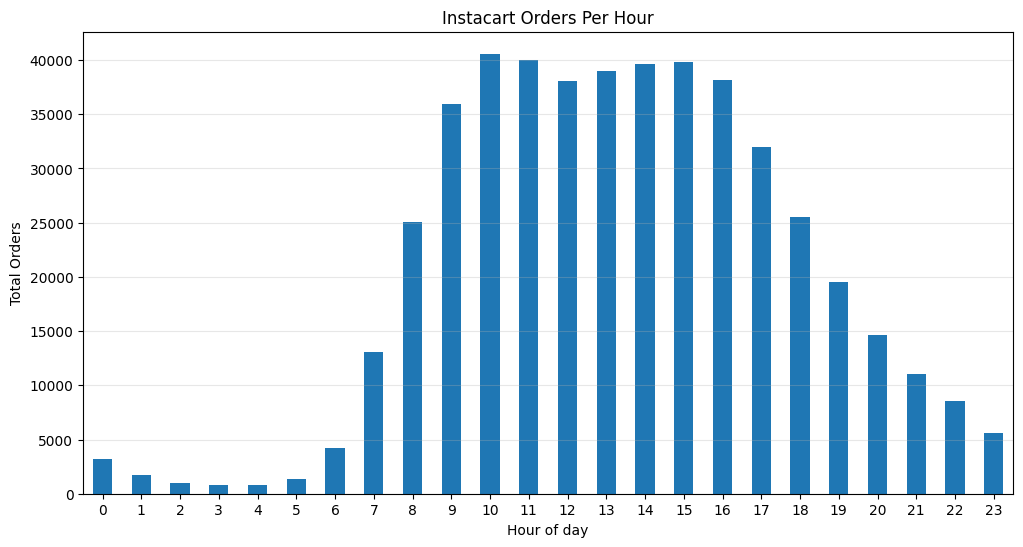

In [33]:
orders_per_hour = orders['order_hour_of_day'].value_counts().sort_index()
# creates the dataframe for the graph
orders_graph = pd.DataFrame({ 'Hour': orders_per_hour.index,
                 'Orders per hour': orders_per_hour.values})

#considered altering the x-axis to be more readable

orders_graph.plot(x='Hour', y='Orders per hour', kind='bar', figsize=(12, 6), 
                  title="Instacart Orders Per Hour", ylabel='Total Orders', 
                  xlabel='Hour of day', legend=False)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.show()


Most orders occur between 9:00 AM and 5:00 PM, with peaks at 10:00 AM and 3:00 PM

### What Day of the Week Do People Shop for Groceries?

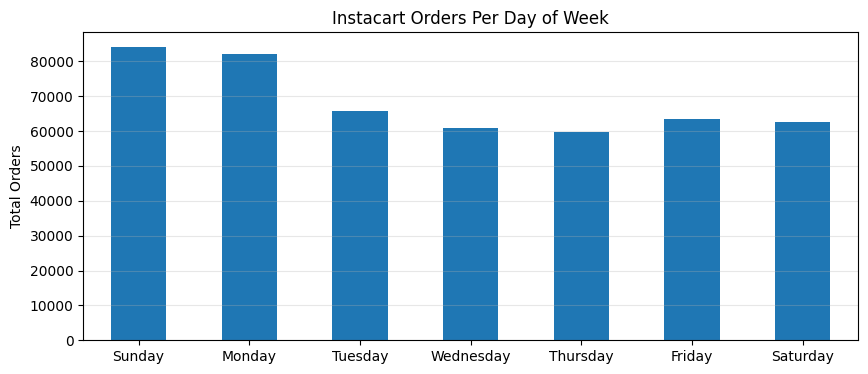

In [34]:
orders_per_day = orders['order_dow'].value_counts().sort_index()
# creates the dataframe for the graph
orders_day_graph = pd.DataFrame({ 'Day': ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'],
                 'Orders per day': orders_per_day.values})

orders_day_graph.plot(x='Day', y='Orders per day', kind='bar', figsize=(10, 4), 
                  title="Instacart Orders Per Day of Week", ylabel='Total Orders', xlabel = "", legend=False)
# omitting x-label because it seems somewhat obvious because of the title
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.show()

The data dictionary does not state which integer corresponds to which day of the week. Assuming Sunday = 0, then people place more orders at the beginning of the week (Sunday and Monday).

### How Long Do People Wait Before Placing Another Order?

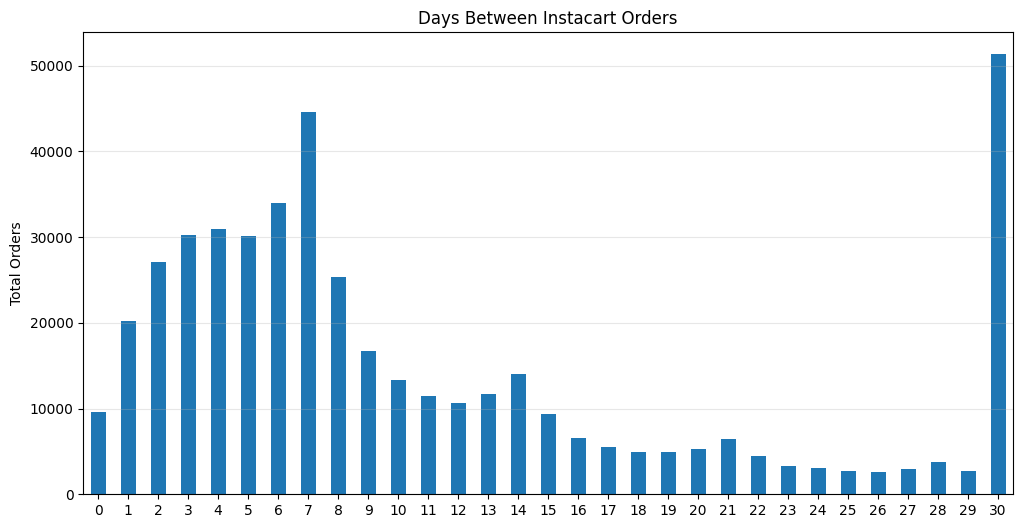

In [35]:
days_since_order = orders['days_since_prior_order'].dropna().value_counts().sort_index()
# creates the dataframe for the graph
orders_graph = pd.DataFrame({ 'Days': days_since_order.index.astype(int),
                 'Orders': days_since_order.values})

orders_graph.plot(x='Days', y='Orders', kind='bar', figsize=(12, 6), 
                  title="Days Between Instacart Orders", ylabel='Total Orders', 
                  xlabel='', legend=False)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.show()

The 0 values probably correspond to customers who placed more than one order on the same day.

The max value of 30 days and the high spike at that value is puzzling though. The spike might be explained by people who set up recurring subscriptions to automatically order once a month. But that doesn't explain why there are no values above 30 days. I would expect many customers to place orders less often than once a month. Maybe those customers were intentionally excluded from the dataset.

Disregarding the spike at 30 days, most people wait between 2 to 10 days in between orders. The most common wait time is 7 days. In other words, it's common for people to place weekly grocery orders. Interestingly, in the tail of the distribution we also see small spikes at 14, 21, and 28 days. These would correspond to orders every 2, 3, or 4 weeks.

## Comparative Analyses

### Difference in Order-Hour Distributions: Wednesday vs Saturday

In [36]:
mask_wed = orders['order_dow'] == 3
mask_sat = orders['order_dow'] == 6

In [37]:
orders_per_wed = orders[mask_wed]['order_hour_of_day'].value_counts().sort_index()

In [38]:
orders_per_sat = orders[mask_sat]['order_hour_of_day'].value_counts().sort_index()

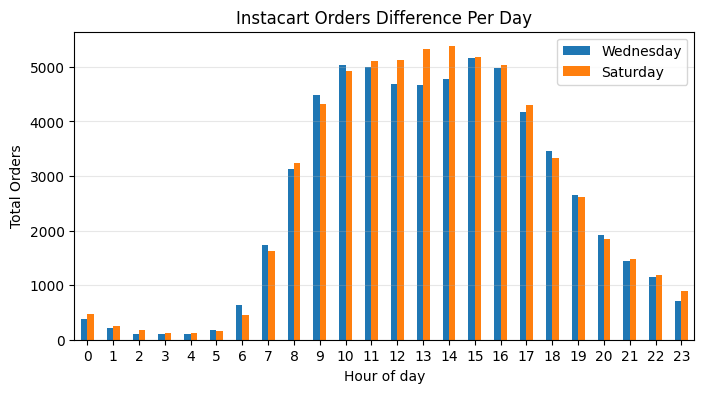

In [39]:
orders_compare = pd.concat([orders_per_wed, orders_per_sat], axis='columns')
orders_compare.columns = ['Wed', 'Sat']


orders_compare.plot(y=orders_compare.columns, kind='bar', figsize=(8, 4), 
                  title="Instacart Orders Difference Per Day", ylabel='Total Orders', 
                  xlabel='Hour of day', legend=False)
plt.grid(axis='y', alpha=0.3)
plt.legend(['Wednesday', 'Saturday'])
plt.xticks(rotation=0)
plt.show()

There's a small dip from 11h to 13h on Wednesdays. This dip is absent on Saturdays. Maybe this dip can be attributed to people who don't use Instacart because they have lunch somewhere between 11h and 13h.

### Distribution of Number of Orders per Customer

In [40]:
order_distribution = orders.groupby('user_id')['order_id'].count().sort_values()

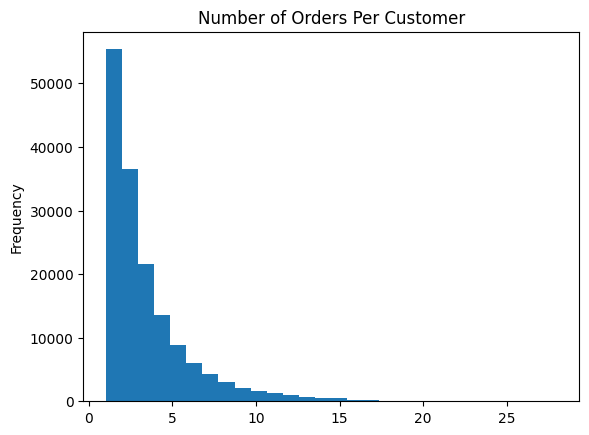

In [41]:
order_distribution.plot(kind='hist', bins=28, title = 'Number of Orders Per Customer', ylabel= 'Orders')
plt.show()
#left the x-label unmarked as it is the title

Most customers in the dataset have placed between 1 and 10 orders, with number of orders per customer sharply decreasing after just 1 order.

### Top 20 Most Popular Products (ID and Name)

In [42]:
valid_products = order_products[order_products['product_id'].isin(products['product_id'])]
popular_orders = valid_products.merge(products, on='product_id')

In [43]:
popular_orders = popular_orders.groupby(['product_id', 'product_name']).size().sort_values(ascending=False)

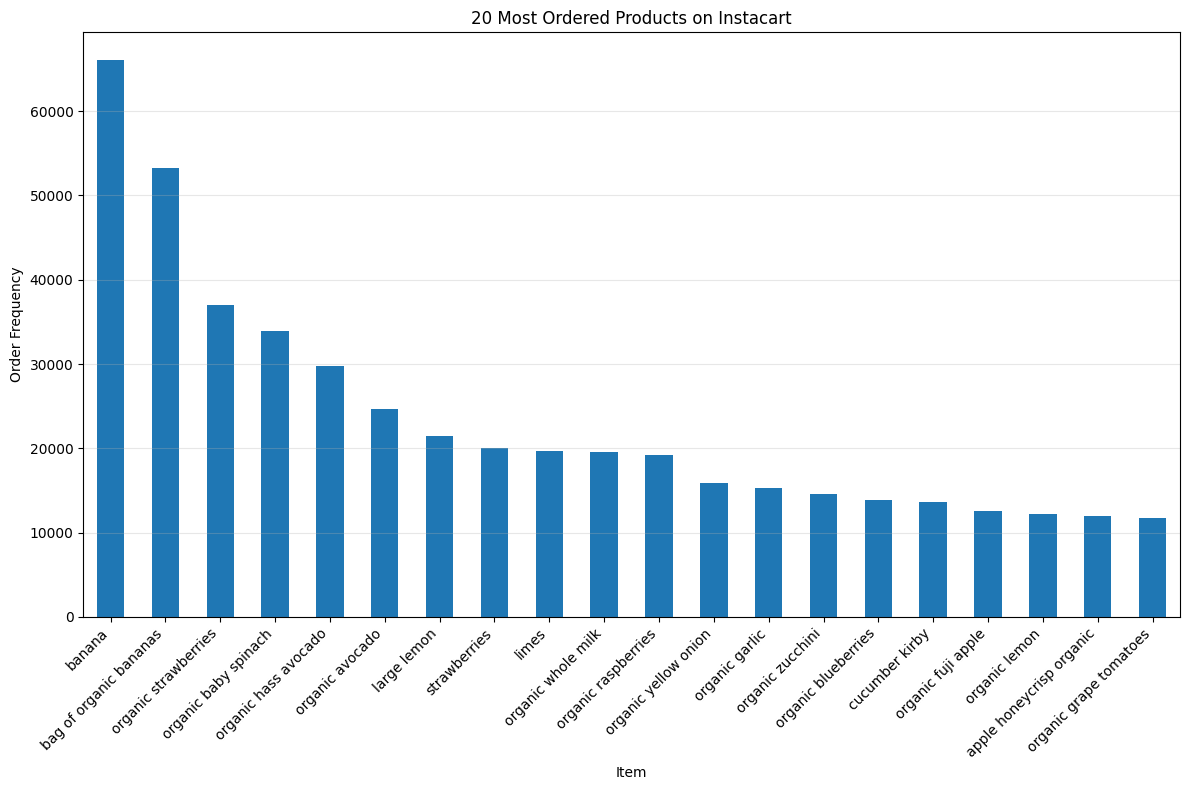

In [57]:
top_20 = popular_orders.head(20).reset_index()
#resetting the index to convert from series to dataframe
top_20.plot(x='product_name', y=0, kind='bar', title='20 Most Ordered Products on Instacart', 
                    xlabel='Item', ylabel='Order Frequency', legend=None, figsize=(12,8))


plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



The top 20 items are all produce, except for the milk. Looks like people want delicious and nutritious!

## Advanced Analyses

### Typical Number of Items per Order and Distribution

In [45]:
order_average = order_products.groupby('order_id')['product_id'].count()

In [46]:
order_average_count = order_average.value_counts().sort_index()
order_average_count = order_average_count[:35]

Most of the order numbers are in the tail of the distribution. To get a better look at the non-tail part, let's choose a value in the tail as a cutoff and just plot order with fewer than that many items. An order size of 35 items is far enough into the tail for this.

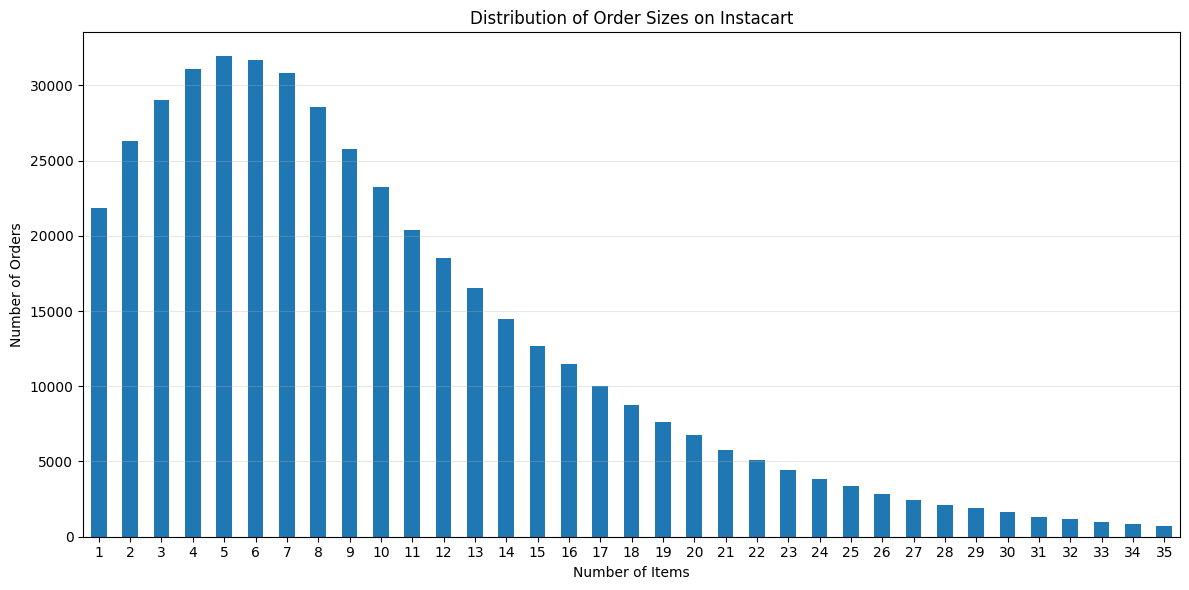

In [47]:
order_average_count.plot(kind='bar', title='Distribution of Order Sizes on Instacart',
                         xlabel='Number of Items', ylabel='Number of Orders', figsize=(12,6)
                        )
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The typical order contains 5 or 6 items, with most orders having between 1 and 20 items.

### Top 20 Most Frequently Reordered Items (ID and Name)

In [48]:
reorder_mask = order_products['reordered']==1
top_reordered = order_products[reorder_mask]

In [49]:
top_reordered_merge = top_reordered.merge(products, on='product_id')

In [50]:
top_reordered = top_reordered_merge.groupby(['product_id', 'product_name']).size().sort_values(ascending=False)
top_reordered = top_reordered.head(20).reset_index()

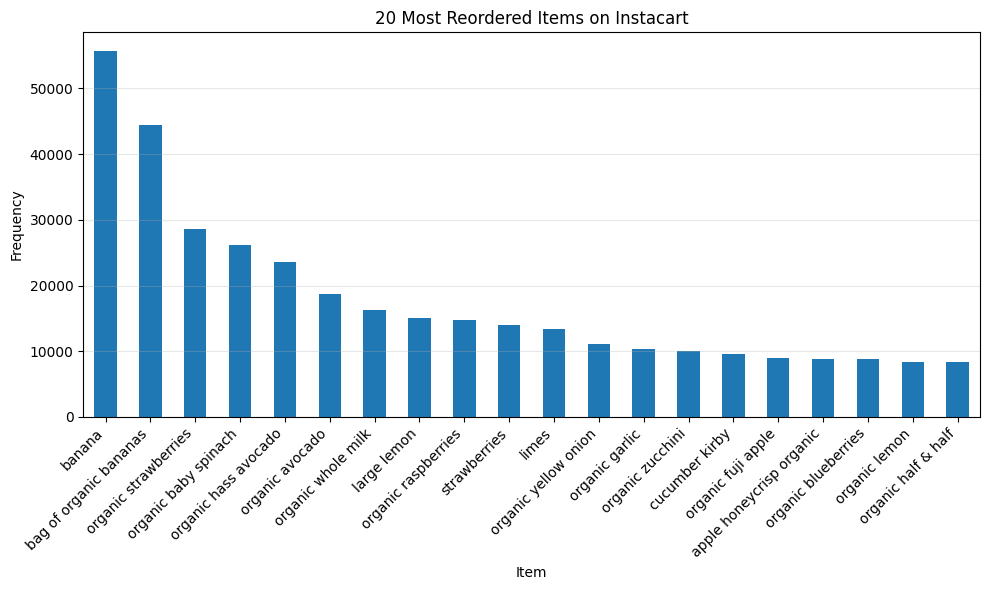

In [51]:
top_reordered.plot(y=0, x='product_name', kind='bar', title='20 Most Reordered Items on Instacart', 
                   xlabel='Item', ylabel='Frequency', legend=False, figsize=(10,6))
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


It looks like produce and dairy comprise the most reordered products as well. It makes sense that perishables would be the most reordered items.

### Reorder Proportion by Product

In [52]:
reorder = order_products.merge(products)
reorder_proportion = reorder.groupby(['product_id', 'product_name'])

In [53]:
reorder_proportion = reorder_proportion['reordered'].mean().sort_values(ascending=False)

In [54]:
reorder_proportion.reset_index()

,product_id,product_name,reordered
0,18121,jalapenos with sea salt,1.0
1,27387,banana greek nonfat yogurt,1.0
2,17773,quinoa- with olive oil,1.0
3,49063,rosemary & sea salt crackers,1.0
4,14935,kombucha blueberry basil,1.0
...,...,...,...
44511,25053,frost arctic blitz sports drink,0.0
44512,25051,herb for beef gravy mix,0.0
44513,25045,bandages- waterproof,0.0
44514,25044,pure pacific mountain strawberry preserves,0.0


### Reorder Proportion by Customer

### Top 20 Products Added to Cart First

The products that are most often placed into the cart first are produce, dairy, and beverages such as soda or water. I couldn't really say why that is without experience using Instacart because this could have more to do with app design than properties of the products. I do notice that there is considerable overlap between this result and the previous result for most popular and most reordered item types. It could simply be that the app prioritizes popular items as the first suggested purchases, so it happens to be more convenient for customers to place these items in their cart first.